## Příprava prostředí

Před spuštěním notebooku nainstalujte závislosti z kořenového adresáře projektu:

```bash
pip install -r requirements.txt
```

# Analýza detekce mytí rukou - Výsledky Baseline modelu

Tento notebook dokumentuje proces vývoje a vyhodnocení základního algoritmu pro detekci mytí rukou v rámci bakalářské práce.

## 1. Cíl projektu
Automatická detekce hygienických návyků (mytí rukou) ve výrobním prostředí. Postupujeme od jednoduchého pohybu k pokročilé AI detekci.

## 2. Příprava dat (Ground Truth)
Bylo vytvořeno a ručně anotováno celkem **162 video klipů**.
- Zdroj: Průmyslová kamera nad umyvadlem.
- Anotace: Vlastní nástroj `src/annotate.py`.

In [ ]:
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Přidání kořene projektu do PYTHONPATH pro import config
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from config import OUTPUTS_DIR

# Načtení anotací
annotations_path = OUTPUTS_DIR / "annotations.json"
with open(annotations_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

total_clips = len(data)
clips_with_wash = sum(1 for v in data.values() if len(v['events']) > 0)

print(f"Celkový počet klipů: {total_clips}")
print(f"Klipy s detekovaným mytím: {clips_with_wash}")
print(f"Klipy bez aktivity: {total_clips - clips_with_wash}")

Celkový počet klipů: 162
Klipy s detekovaným mytím: 41
Klipy bez aktivity: 121


## 3. Výsledky Baseline modelu (Detekce na základě pohybu)

Algoritmus používá odečítání pozadí (MOG2) v definované oblasti zájmu (ROI).

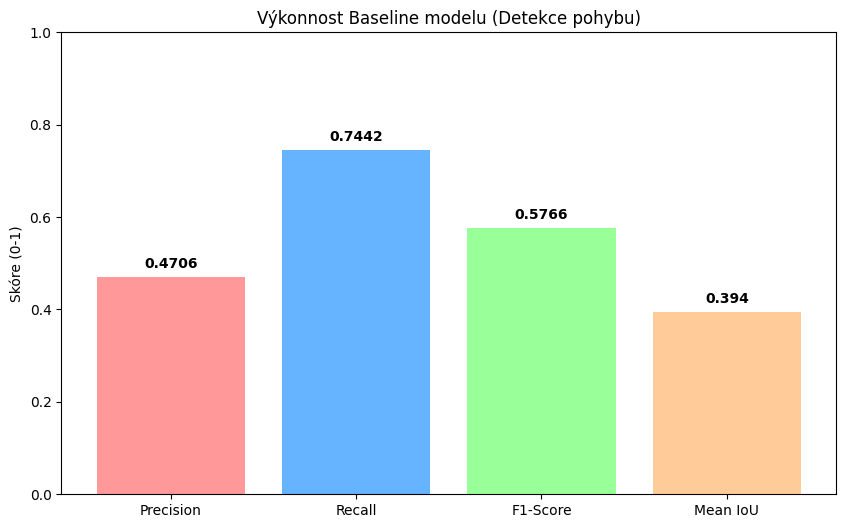

In [ ]:
results = {
    "Metrika": ["Precision", "Recall", "F1-Score", "Mean IoU"],
    "Hodnota": [0.4706, 0.7442, 0.5766, 0.3940]
}
df_metrics = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.bar(df_metrics["Metrika"], df_metrics["Hodnota"], color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.ylim(0, 1)
plt.title("Výkonnost Baseline modelu (Detekce pohybu)")
plt.ylabel("Skóre (0-1)")
for i, v in enumerate(df_metrics["Hodnota"]):
    plt.text(i, v + 0.02, str(v), color='black', fontweight='bold', ha='center')
plt.show()

## 4. Portování na AI modely a finální výsledky

V této části porovnáváme vývoj od jednoduché detekce pohybu k pokročilému AI modelu. Soap Trigger detektor dosáhl nejlepších výsledků díky fine-tuningu parametrů (min-duration 3s) a čištění datasetu.

Evoluce přesnosti detekce mytí rukou (Fine-tuningem zvýšena Precision o 25 %):


,Precision,Recall,F1-Score,Mean IoU
Detector,,,,
1. Baseline (MOG2),0.5333,0.7442,0.6214,0.3940
2. MediaPipe Hands,0.5091,0.6512,0.5714,0.4009
3. Soap Trigger (Base),0.6250,0.5814,0.6024,0.6645
4. Soap Trigger (Final),0.8710,0.6279,0.7297,0.6610


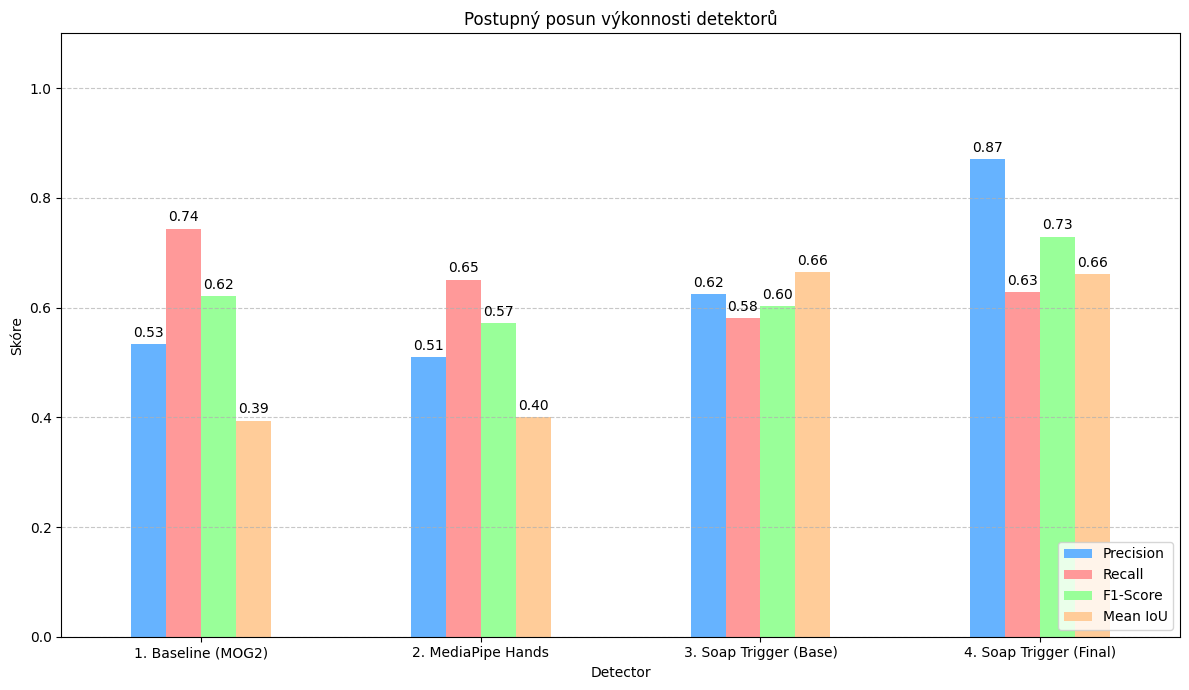

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_results = {
    "Detector": ["1. Baseline (MOG2)", "2. MediaPipe Hands", "3. Soap Trigger (Base)", "4. Soap Trigger (Final)"],
    "Precision": [0.5333, 0.5091, 0.6250, 0.8710],
    "Recall": [0.7442, 0.6512, 0.5814, 0.6279],
    "F1-Score": [0.6214, 0.5714, 0.6024, 0.7297],
    "Mean IoU": [0.3940, 0.4009, 0.6645, 0.6610]
}

df_comp = pd.DataFrame(comparison_results)
df_comp.set_index("Detector", inplace=True)

print("Evoluce přesnosti detekce mytí rukou (Fine-tuningem zvýšena Precision o 25 %):")
display(df_comp)

ax = df_comp.plot(kind="bar", figsize=(12, 7), color=['#66b3ff', '#ff9999', '#99ff99', '#ffcc99'])
plt.title("Postupný posun výkonnosti detektorů")
plt.ylabel("Skóre")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

## 4. Analýza chyb a další kroky

**Zjištění:**
- Model má vysoký **Recall (74%)** - většinu mytí zachytí.
- Model má nízkou **Precision (47%)** - polovina hlášení jsou falešné poplachy (stíny, odlesky vody).

**Realizované vylepšení — MediaPipe Hands detektor:**
Implementován AI-enhanced detektor (`mediapipe_detector.py`), který kombinuje MOG2 detekci pohybu s detekcí rukou pomocí Google MediaPipe Hands. Událost je zaznamenána pouze pokud je v ROI detekován pohyb **A ZÁROVEŇ** jsou přítomny lidské ruce. Tím se eliminují falešné poplachy způsobené neživými objekty.

## 5. Plán: Compliance statistiky pro výrobní provoz

### Varianta A — Anonymní compliance monitoring (v realizaci)
Propojení wash událostí s průchody osob přes exit zónu (YOLO person detector):
- **Compliance rate** — % průchodů s předchozím mytím rukou
- **Compliance per směna** — ranní / odpolední / noční
- **Průměrná délka mytí** — WHO doporučuje ≥20s
- **Trend v čase** — např. měření efektu školení

### Varianta B — Pseudonymní tracking (připraveno k rozšíření)
Pro regulované provozy (farmacie, potravinářství) je možnost rozšíření o multi-object tracking (ByteTrack/DeepSORT + YOLO), který umožní sledování na úrovni pseudonymních ID bez rozpoznávání obličejů. Viz `README.md` sekce „Compliance statistiky".